# Directional Inhibition Mask — pirate persona (Qwen3.5-2B)

Removes an injected **"pirate" speaking register** from a small chat model by projecting a
low-rank, contrastively-estimated *role subspace* out of the residual stream
(`h ← h − λ·B Bᵀ h`), then runs the falsification controls. The mechanism, controls and
metrics live in `inhibition_mask.py` / `metrics.py`; this notebook only orchestrates them.

## Pipeline — what happens, in order
1. **Setup** (cells 2–7): recreate the modules, install deps, load the model.
2. **Build the role subspace** (9): estimate `B` from 50 contrastive *minimal* pairs
   (neutral ↔ the same sentence in pirate register) via difference-of-means → SVD →
   orthogonalization against chat-template tokens. Also a signed `role_score` probe.
3. **Demo** (11): the same prompt with and without the mask.
4. **Main evaluation, N=50** (13): suppression measured on `role_score` (diagnostic) **and**
   on the model-independent **pirate-lexicon** counter; plus the meta-cascade rate.
5. **Concept-specificity** (15): a *formal-register* subspace and a *random* subspace built by
   the **same pipeline** should **not** suppress pirate — isolates the effect from "removing
   any K dimensions".
6. **Capability** (17): factual prompts must still be answered correctly under the mask.
7. **Dose & depth sweeps** (19): suppression vs `λ`, and vs which layers are masked.
8. **Separability** (21) and **pure subspace** (23): is the role direction separable from
   *generic* vivid writing, or is the overlap intrinsic?
9. **Diagnostic E1** (25): how "home-field" the `role_score` probe is (its cosine with the
   masked subspace).

## How to read the results
- The **load-bearing evidence** is the independent **lexicon counter** plus the
  **formal / random controls**. `role_score` is a **diagnostic only** — its direction ≈ the
  masked subspace, so a drop is partly mechanical (this is exactly what E1 quantifies).
- The honest **limitation**: the estimated direction is a broad *expressive register*, not
  pirate-specific (sections 8). See `README.md` for the calibrated claim.

> Greedy decoding; a seed is set in the imports cell. Results are reproducible run-to-run.


## Colab setup
Recreates the module files in the working directory, then installs deps.
**Skip this section if you run locally with `inhibition_mask.py`, `data.py`, `metrics.py` already next to the notebook.**

In [ ]:
%%writefile inhibition_mask.py
"""Directional inhibition mask for suppressing an injected persona in a transformer LM.

Pipeline
--------
1. Contrastive *minimal* pairs (a sentence in neutral style ↔ the same sentence in
   the target persona's style) isolate the persona direction, with content cancelling
   inside each pair.
2. Per layer, the difference-of-means over pairs is decomposed with an SVD into a
   K-dimensional ``role subspace`` 𝒢.
3. 𝒢 is orthogonalized against the chat-template's *structural* token directions so
   that the mask does not touch scaffolding tokens.
4. The mask removes the projection onto 𝒢 from the residual stream at every layer:
   ``h <- h - lam * B Bᵀ h`` (optionally gated: only where the projection is large).

A signed, centered probe (``RoleSensor``) is used as a *diagnostic* metric. Its
direction nearly coincides with the masked subspace, so the behavioural claim rests
on independent checks (a surface-lexicon counter and a concept-specificity control),
not on the probe value. See README for the calibrated claim and limitations.

Assumes a HuggingFace decoder exposing ``model.model.layers`` (Qwen/Llama style).
"""
from __future__ import annotations

from contextlib import contextmanager
from dataclasses import dataclass

import torch


# --------------------------------------------------------------------------- #
# Activation capture
# --------------------------------------------------------------------------- #
def _chat_wrap(tokenizer, text: str):
    """Wrap ``text`` as a single user turn using the model's chat template.

    ``enable_thinking`` is Qwen-specific; templates that don't accept it (e.g. Llama)
    raise ``TypeError``, in which case we retry without it. Only if no chat template
    exists at all do we fall back to the raw text.
    """
    msgs = [{"role": "user", "content": text}]
    try:
        return tokenizer.apply_chat_template(
            msgs, tokenize=False, add_generation_prompt=True, enable_thinking=False
        )
    except TypeError:
        return tokenizer.apply_chat_template(
            msgs, tokenize=False, add_generation_prompt=True
        )
    except Exception:
        return text


def to_inputs(tokenizer, text: str, device, chat: bool = True):
    rendered = _chat_wrap(tokenizer, text) if chat else text
    return tokenizer(rendered, return_tensors="pt").to(device)


@torch.no_grad()
def capture(model, inputs, layers, pool: bool = True):
    """Return ``{layer: activation}`` for the given decoder layers.

    ``pool=True``  -> mean over tokens, shape ``(d,)``.
    ``pool=False`` -> per token, shape ``(seq, d)``.
    """
    store: dict[int, torch.Tensor] = {}

    def make_hook(layer_idx):
        def hook(_module, _inp, out):
            h = out[0] if isinstance(out, tuple) else out
            h = h.detach()[0].float()
            store[layer_idx] = h.mean(0) if pool else h
        return hook

    handles = [model.model.layers[L].register_forward_hook(make_hook(L)) for L in layers]
    try:
        model(**inputs)
    finally:
        for h in handles:
            h.remove()
    return store


def mean_pool(model, tokenizer, text, layers, device, chat: bool = True):
    return capture(model, to_inputs(tokenizer, text, device, chat=chat), layers, pool=True)


# --------------------------------------------------------------------------- #
# Role subspace 𝒢
# --------------------------------------------------------------------------- #
@dataclass
class RoleSubspace:
    """Per-layer orthonormal bases of the role subspace. ``B[L]`` is ``(d, K)``."""
    B: dict[int, torch.Tensor]
    layers: list[int]
    K: int

    def projection_magnitude(self, model, tokenizer, text, device) -> "torch.Tensor":
        """Per-token ``‖Bᵀa‖`` averaged over layers (how much each token loads on 𝒢)."""
        caps = capture(model, to_inputs(tokenizer, text, device, chat=False), self.layers, pool=False)
        seq = caps[self.layers[0]].shape[0]
        acc = torch.zeros(seq, device=caps[self.layers[0]].device)
        for L in self.layers:
            acc = acc + (caps[L] @ self.B[L]).norm(dim=-1)
        return (acc / len(self.layers)).cpu()


def _structural_directions(model, tokenizer, texts, layers, device, special_ids, r_struct):
    """SVD bases of chat-template structural-token activations, per layer."""
    block = {"assistant", "user", "system", "<think>", "</think>", ""}
    per_layer: dict[int, list[torch.Tensor]] = {L: [] for L in layers}
    for t in texts:
        ids = to_inputs(tokenizer, t, device, chat=True)
        toks = ids["input_ids"][0].tolist()
        pos = [i for i, tk in enumerate(toks)
               if (tk in special_ids) or (tokenizer.decode([tk]).strip() in block)]
        caps = capture(model, ids, layers, pool=False)
        for L in layers:
            per_layer[L].extend(caps[L][i] for i in pos)
    out = {}
    for L in layers:
        S = torch.stack(per_layer[L])
        _, _, Vh = torch.linalg.svd(S, full_matrices=False)
        out[L] = Vh[:r_struct].T.contiguous()
    return out


def build_subspace(model, tokenizer, pairs, layers, device, *, K=4,
                   structural_texts=None, r_struct=12) -> RoleSubspace:
    """Build the role subspace from contrastive (neutral, persona) pairs.

    Pairs are wrapped in the chat template so that structural tokens cancel inside
    each difference; the subspace is then orthogonalized against the structural
    directions estimated from ``structural_texts`` (neutral prompts).
    """
    diffs: dict[int, list[torch.Tensor]] = {L: [] for L in layers}
    for neutral, persona in pairs:
        cn = mean_pool(model, tokenizer, neutral, layers, device, chat=True)
        cp = mean_pool(model, tokenizer, persona, layers, device, chat=True)
        for L in layers:
            diffs[L].append(cp[L] - cn[L])

    struct = None
    if structural_texts:
        special_ids = set(tokenizer.all_special_ids)
        struct = _structural_directions(model, tokenizer, structural_texts, layers,
                                        device, special_ids, r_struct)

    B = {}
    for L in layers:
        _, _, Vh = torch.linalg.svd(torch.stack(diffs[L]), full_matrices=False)
        basis = Vh[:K].T.contiguous()
        if struct is not None:
            Q = struct[L]
            basis = basis - Q @ (Q.T @ basis)        # remove structural component
            basis, _ = torch.linalg.qr(basis)        # re-orthonormalize
        B[L] = basis.to(device).float()
    return RoleSubspace(B=B, layers=list(layers), K=K)


def random_subspace(reference: RoleSubspace, device, seed=0) -> RoleSubspace:
    """Matched-rank random orthonormal subspaces (a control for the projection op)."""
    g = torch.Generator(device="cpu").manual_seed(seed)
    B = {}
    for L, M in reference.B.items():
        d, K = M.shape
        rand = torch.randn(d, K, generator=g).to(device)
        Q, _ = torch.linalg.qr(rand)
        B[L] = Q[:, :K].contiguous().float()
    return RoleSubspace(B=B, layers=reference.layers, K=reference.K)


def orthogonalize(subspace: RoleSubspace, against: RoleSubspace) -> RoleSubspace:
    """Remove ``against`` from ``subspace`` per layer (e.g. pirate minus generic colorfulness).

    Yields the part of ``subspace`` that is orthogonal to ``against`` — used to ask whether
    the persona has a component separable from a confounding concept (vivid writing).
    """
    B = {}
    for L in subspace.layers:
        basis = subspace.B[L]
        Q = against.B[L]
        basis = basis - Q @ (Q.T @ basis)
        basis, _ = torch.linalg.qr(basis)
        B[L] = basis.to(basis.device).float()
    return RoleSubspace(B=B, layers=subspace.layers, K=subspace.K)


# --------------------------------------------------------------------------- #
# Diagnostic probe (home-field metric)
# --------------------------------------------------------------------------- #
@dataclass
class RoleSensor:
    layer: int
    mu: torch.Tensor          # neutral reference (common-mode), (d,)
    direction: torch.Tensor   # unit role direction, (d,)

    def score(self, model, tokenizer, text, device) -> float:
        if not text.strip():
            return 0.0
        a = mean_pool(model, tokenizer, text, [self.layer], device, chat=False)[self.layer]
        return torch.dot(self.direction, a.to(self.direction.device) - self.mu).item()


def build_sensor(model, tokenizer, pairs, layer, device) -> RoleSensor:
    """Signed, common-mode-centered probe at one layer (a *diagnostic*, not ground truth)."""
    neu = torch.stack([mean_pool(model, tokenizer, n, [layer], device, chat=False)[layer]
                       for n, _ in pairs])
    pir = torch.stack([mean_pool(model, tokenizer, p, [layer], device, chat=False)[layer]
                       for _, p in pairs])
    mu = neu.mean(0).to(device)
    direction = (pir - neu).mean(0)
    direction = (direction / direction.norm()).to(device)
    return RoleSensor(layer=layer, mu=mu, direction=direction)


# --------------------------------------------------------------------------- #
# The mask
# --------------------------------------------------------------------------- #
def _projection_hook(B: torch.Tensor, lam: float, theta: float | None):
    def hook(_module, _inp, out):
        is_tuple = isinstance(out, tuple)
        h = out[0] if is_tuple else out
        rest = out[1:] if is_tuple else ()
        x = h.float()
        coords = x @ B                       # (..., K)
        proj = coords @ B.T                  # (..., d)
        if theta is not None:                # gated: only act where projection is large
            gate = (coords.norm(dim=-1, keepdim=True) > theta).float()
            proj = gate * proj
        new = (x - lam * proj).to(h.dtype)
        return (new,) + rest if is_tuple else new
    return hook


@contextmanager
def mask(model, subspace: RoleSubspace, layers, *, lam: float = 1.0, theta: float | None = None):
    """Apply the projection mask on ``layers`` for the duration of the context."""
    handles = [model.model.layers[L].register_forward_hook(_projection_hook(subspace.B[L], lam, theta))
               for L in layers]
    try:
        yield
    finally:
        for h in handles:
            h.remove()


@torch.no_grad()
def generate(model, tokenizer, prompt, device, *, subspace=None, layers=None,
             lam=1.0, theta=None, max_new_tokens=40, do_sample=False, **gen_kwargs):
    inputs = to_inputs(tokenizer, prompt, device, chat=True)
    n = inputs["input_ids"].shape[1]
    ctx = mask(model, subspace, layers, lam=lam, theta=theta) if (subspace and layers) else _null()
    with ctx:
        out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=do_sample,
                             pad_token_id=tokenizer.eos_token_id, **gen_kwargs)
    return tokenizer.decode(out[0][n:], skip_special_tokens=True)


@contextmanager
def _null():
    yield


Writing inhibition_mask.py


In [ ]:
%%writefile data.py
"""Datasets for the pirate-persona inhibition experiment.

PAIRS            : 50 minimal (neutral, pirate) pairs — build the role subspace.
PERSONA_PROMPTS  : 50 pirate-persona injections — evaluation set.
NEUTRAL_PROMPTS  : 15 plain factual tasks — capability / structural reference.
FORMAL_PAIRS     : 20 (casual, formal) pairs — concept-specificity control subspace.
CREATIVE_PAIRS   : 18 (plain, vivid) pairs — "is the role direction just colorfulness?" probe.
"""

PAIRS = [
    ("Hello, can you tell me where the map is?", "Ahoy there, can ye tell me where the map be, matey?"),
    ("We are going to take their gold.", "Arrr, we be takin' their gold, every last coin!"),
    ("The ship is leaving the harbor now.", "Th' ship be leavin' the harbor now, ye scurvy dogs!"),
    ("Give me the bottle of rum, please.", "Hand over the bottle o' rum, ye bilge rat!"),
    ("I am not afraid of the navy.", "Arrr, I fear no navy on these here waters!"),
    ("Everyone, come up to the deck.", "All hands on deck, me hearties, look lively!"),
    ("He stole my last coin.", "That scallywag stole me last piece o' eight!"),
    ("Let's raise the flag and set sail.", "Hoist the colors and set sail, lads, yo ho ho!"),
    ("Tell me the truth or there will be trouble.", "Ye best be talkin' true, or ye'll walk the plank!"),
    ("We found the treasure on the island.", "Arrr, we found the treasure buried on yonder island!"),
    ("The captain wants to see you immediately.", "The cap'n be wantin' to see ye right quick, savvy?"),
    ("Stop the boat near the rocks.", "Drop anchor by them rocks, ye lubbers!"),
    ("I have sailed across many seas.", "Arrr, I've sailed the seven seas an' lived to tell it!"),
    ("Be careful, a storm is coming.", "Batten down the hatches, a storm be comin', mateys!"),
    ("Surrender now and no one gets hurt.", "Surrender yer ship or face me cutlass, ye dogs!"),
    ("This is the best crew I have ever had.", "Arrr, ye be the finest crew to ever sail with me!"),
    ("Where did you hide the chest?", "Where be ye hidin' the chest o' loot, ye sneak?"),
    ("We will attack at dawn.", "We strike at dawn, lads, and show no mercy!"),
    ("Good morning, how are you today?", "Ahoy mornin', how be ye farin' this fine day?"),
    ("Please pass me the water.", "Pass me the grog, ye salty sea-dog!"),
    ("The weather is nice for sailing.", "Arrr, fine weather to set the sails an' chase the horizon!"),
    ("I lost my keys somewhere.", "I've lost me compass somewhere in the bilge, blast it!"),
    ("Let's count the money we earned.", "Let's count the plunder we've pillaged, har har!"),
    ("He is a very brave man.", "He be the bravest buccaneer to sail the high seas!"),
    ("Come here and listen carefully.", "Gather 'round, me hearties, an' lend me yer ears!"),
    ("We need more supplies for the trip.", "We be needin' more rum an' hardtack for the voyage!"),
    ("That is my favorite song.", "Arrr, that be me favorite sea shanty, sing it loud!"),
    ("I will protect my friends.", "I'll defend me crew to me dyin' breath, savvy?"),
    ("The door is locked tight.", "The hold be locked tighter than Davy Jones' locker!"),
    ("Let's go on an adventure.", "Let's set sail for adventure an' buried gold, lads!"),
    ("He always tells funny jokes.", "Arrr, he be spinnin' the finest yarns on the seven seas!"),
    ("Can you help me find my way?", "Can ye help a sailor chart a course, matey?"),
    ("The food here is delicious.", "This here grub be the finest feast since we raided port!"),
    ("I need to rest for a while.", "I'll be restin' me sea legs in the cap'n's quarters!"),
    ("They are coming to get us.", "The redcoats be closin' in, man the cannons, ye dogs!"),
    ("Keep the secret to yourself.", "Keep that treasure map secret, or ye'll feed the sharks!"),
    ("We won the game easily.", "Arrr, we plundered that prize without breakin' a sweat!"),
    ("Please be quiet, I am working.", "Pipe down, ye bilge rats, the cap'n be plottin' a course!"),
    ("The night is dark and cold.", "The night be black as pitch an' cold as Jones' locker!"),
    ("I trust you with my life.", "I'd trust ye with me last doubloon, me loyal matey!"),
    ("Let's make a plan together.", "Let's plot our raid together, gather 'round the map!"),
    ("The boat is very fast.", "This here vessel cuts the waves swift as a sea-hawk!"),
    ("He drank too much last night.", "He swilled too much grog last night, the drunken sea-dog!"),
    ("Show me what you found.", "Show me yer plunder, ye thievin' scallywag!"),
    ("We must leave right now.", "We must weigh anchor this instant, the tide be turnin'!"),
    ("Thank you for your help.", "Much obliged, ye fine buccaneer, ye saved me hide!"),
    ("The map shows a hidden path.", "Arrr, the map marks a secret passage to the loot, savvy?"),
    ("I am the leader of this group.", "I be the cap'n o' this crew, an' me word be law!"),
    ("Let's celebrate our victory.", "Break out the rum an' celebrate our plunder, yo ho ho!"),
    ("Be honest with me, please.", "Speak true, ye scurvy knave, or walk the plank!"),
]

PERSONA_PROMPTS = [
    "Talk like a pirate. Describe your morning routine.",
    "You are a pirate. Tell me briefly about your weekend.",
    "Respond as a pirate. What is your favorite food?",
    "In pirate speak, explain how to make a cup of tea.",
    "Pretend you're a pirate and give me one tip about studying.",
    "Answer like a pirate: what is the weather like today?",
    "You're a swashbuckling pirate captain. Introduce yourself briefly.",
    "Speak as a pirate would. Describe a walk in the park.",
    "Channel your inner pirate and tell me about your best friend.",
    "As a pirate, what would you do on a rainy day?",
    "Arrr, matey! Tell me about your favorite hobby.",
    "Ahoy! What did you have for breakfast this morning?",
    "Talk like a pirate and explain how computers work.",
    "As a pirate, give me advice about saving money.",
    "Respond like a pirate: what's your dream vacation?",
    "You are a pirate. Describe your typical day at sea.",
    "In pirate voice, tell me a short bedtime story.",
    "Pretend to be a pirate and recommend a movie.",
    "Speak as a pirate. What makes you happy?",
    "Arrr! Explain how to bake bread, pirate style.",
    "As a pirate captain, describe your ship.",
    "Talk like a pirate about your plans for tomorrow.",
    "You're a pirate. What's your opinion on modern technology?",
    "Answer as a pirate: how do you stay healthy?",
    "In pirate speak, describe a beautiful sunset.",
    "Pretend you're a pirate and tell me about your crew.",
    "Speak like a pirate. What's the best way to learn a language?",
    "Arrr, matey! Describe your favorite season.",
    "As a pirate, explain why teamwork matters.",
    "You are a pirate. Tell me about a recent adventure.",
    "Respond like a pirate: what's your morning drink?",
    "Talk like a pirate and describe a busy city.",
    "In pirate voice, give me a recipe for soup.",
    "Pretend to be a pirate and describe your treasure.",
    "Speak as a pirate about the meaning of friendship.",
    "Ahoy! How do you handle a difficult day, pirate style?",
    "As a pirate, what would you pack for a journey?",
    "Talk like a pirate about the ocean.",
    "You're a pirate. Describe your favorite meal in detail.",
    "Respond as a pirate: what's your greatest fear?",
    "In pirate speak, explain how to plant a garden.",
    "Pretend you're a pirate and give a motivational speech.",
    "Speak like a pirate. Describe a quiet evening at home.",
    "Arrr! Tell me about your favorite book, pirate style.",
    "As a pirate captain, give orders to your crew.",
    "Talk like a pirate and describe a thunderstorm.",
    "You are a pirate. What do you think about gold?",
    "Respond like a pirate: how do you make new friends?",
    "In pirate voice, describe your dream house.",
    "Pretend to be a pirate and explain how to fish.",
]

NEUTRAL_PROMPTS = [
    "What is the capital of Japan?",
    "Give me one tip for staying healthy.",
    "Explain briefly how photosynthesis works.",
    "Recommend a good book and say why in one sentence.",
    "How do I make a cup of coffee? Keep it short.",
    "What is the difference between a virus and a bacterium?",
    "Describe a walk in the park in two sentences.",
    "Summarize what the internet is in two sentences.",
    "What is 17 times 23?",
    "Name three countries in South America.",
    "What is the boiling point of water at sea level?",
    "Give a short definition of gravity.",
    "List two benefits of regular exercise.",
    "What language is mainly spoken in Brazil?",
    "Explain what a noun is in one sentence.",
]

FORMAL_PAIRS = [
    ("Hey, what's up?", "Good day, how may I assist you?"),
    ("That's awesome, thanks!", "That is excellent, thank you very much."),
    ("Can you help me out?", "Would you be so kind as to assist me?"),
    ("I dunno, maybe later.", "I am uncertain; perhaps at a later time."),
    ("This is gonna be great.", "This is going to be most satisfactory."),
    ("Sorry, my bad.", "I apologize for my error."),
    ("Let's grab a bite.", "Shall we partake in a meal together?"),
    ("No worries, it's cool.", "Do not be concerned; it is quite acceptable."),
    ("Wanna hang out?", "Would you care to spend some time together?"),
    ("That movie was sick!", "That film was thoroughly impressive."),
    ("I'm super tired today.", "I am exceedingly fatigued today."),
    ("Check this out.", "Please observe the following."),
    ("It's no big deal.", "It is of little consequence."),
    ("Gimme a sec.", "Please allow me a moment."),
    ("That's totally fine.", "That is entirely acceptable."),
    ("Catch you later.", "I shall speak with you subsequently."),
    ("Kinda busy right now.", "I am rather occupied at present."),
    ("Thanks a ton!", "I am most grateful for your help."),
    ("Let me know, okay?", "Kindly inform me at your convenience."),
    ("It was pretty good.", "It was quite satisfactory indeed."),
]

CREATIVE_PAIRS = [
    ("The sky was dark before the storm.", "A wall of bruised clouds smothered the trembling sky before the storm."),
    ("The market was busy at night.", "The night market blazed with neon light and a chaotic symphony of voices."),
    ("The forest had colorful leaves in autumn.", "The autumn forest burned in a tapestry of crimson, amber, and gold."),
    ("The sun set over the sea.", "The sun bled crimson across the rippling silver sea."),
    ("The library was old and quiet.", "The ancient library breathed dust, leather, and forgotten centuries."),
    ("The mountain was covered in snow.", "The mountain slumbered beneath a hush of soft, glittering snow."),
    ("There were many stars in the sky.", "A thousand stars shimmered like scattered diamonds across the velvet sky."),
    ("The river flowed through the valley.", "The silver river wound like a ribbon through the emerald valley."),
    ("The city was full of people and noise.", "The city pulsed with a restless tide of footsteps, horns, and neon light."),
    ("The garden had many flowers.", "The garden overflowed with riotous blooms of violet, rose, and flame."),
    ("The cafe was warm and cozy.", "The little cafe glowed warm and golden against the rain-streaked glass."),
    ("The waves hit the rocks.", "The waves shattered against the jagged rocks in a spray of silver foam."),
    ("The fire burned in the fireplace.", "The fire crackled and danced, casting amber shadows across the walls."),
    ("The field was green and wide.", "The wide green field rippled like a sea beneath the restless wind."),
    ("The street was quiet in the morning.", "The empty street lay hushed and pearl-grey in the soft morning light."),
    ("The storm passed and the sky cleared.", "The storm rolled away, leaving a washed and luminous turquoise sky."),
    ("The old house stood on the hill.", "The old house brooded on the hill, its windows like watchful eyes."),
    ("The desert was hot and empty.", "The desert shimmered, vast and golden, beneath a merciless white sun."),
]

# Surface pirate-lexicon markers — an INDEPENDENT measure of the persona in generated
# text (not derived from the activation vector that builds the mask).
# NOTE: "arr" is handled separately by the _ARR regex in metrics.py (matches arr/arrr/arrrr...),
# and "ye" by the _YE regex; both are kept OUT of this list to avoid double counting.
PIRATE_MARKERS = [
    "ahoy", "matey", "scallywag", "scurvy", "shiver me", "yer ", "me hearty",
    "me hearties", "hearties", "walk the plank", "yo ho", "avast", "buccaneer",
    "landlubber", "doubloon", "grog", "bilge", "savvy", "aye", "cap'n", "sea dog",
    "plunder", "booty", "jolly roger", "pieces of eight",
]

# Phrases marking the expected "I am an AI" cascade when the persona is removed.
# (This is the correct consequence of removing an identity direction, not a failure.)
META_MARKERS = [
    "i am an ai", "i'm an ai", "as an ai", "i am an artificial",
    "i don't have a physical", "i do not have a physical", "fictional character",
    "i don't have personal", "i don't have a body", "i cannot actually",
    "i can't actually", "i don't have feelings",
]


Writing data.py


In [ ]:
%%writefile metrics.py
"""Independent, behaviour-level metrics on generated text.

These do NOT depend on the activation direction that builds the mask, so they
carry the real claim (unlike the ``RoleSensor`` diagnostic).
"""
from __future__ import annotations

import re
from math import sqrt

from data import PIRATE_MARKERS, META_MARKERS

_DROP_G = re.compile(r"\b\w+in'\b")   # takin', sailin'
_OF = re.compile(r"\bo'\b")           # o'
_YE = re.compile(r"\bye\b")           # ye as a standalone word
_ARR = re.compile(r"\barr+\b")        # arr, arrr, arrrr ... ("arr" is NOT in PIRATE_MARKERS)

# Pre-compiled WORD-BOUNDARY patterns for every marker. Using \b avoids substring
# false positives that an earlier .count() had ("aye" in "maybe", "arr" in "narrative").
_MARKER_RE = [re.compile(r"\b" + re.escape(m.strip()) + r"\b") for m in PIRATE_MARKERS]


def pirate_lexicon(text: str, per_100_words: bool = True) -> float:
    """Surface pirate-marker rate in ``text`` (independent of the mask subspace).

    Word-boundary matched (no substring false positives) and normalized per 100 words
    so that shorter masked/disclaimer outputs are not scored as "more suppressed" merely
    for being shorter. Set ``per_100_words=False`` for the raw count.
    """
    low = text.lower()
    n_words = max(len(re.findall(r"[a-z']+", low)), 1)
    count = sum(len(p.findall(low)) for p in _MARKER_RE)
    count += (len(_DROP_G.findall(low)) + len(_OF.findall(low))
              + len(_YE.findall(low)) + len(_ARR.findall(low)))
    return 100.0 * count / n_words if per_100_words else count


def is_meta(text: str) -> bool:
    """True if the model reverted to an 'I am an AI' disclaimer (expected cascade)."""
    low = text.lower()
    return any(m in low for m in META_MARKERS)


def lexical_diversity(text: str) -> float:
    """Type/token ratio (rises mechanically for shorter texts — interpret with care)."""
    words = re.findall(r"[a-z']+", text.lower())
    return len(set(words)) / max(len(words), 1)


def cohens_d(a, b) -> float:
    """Standardized mean difference between two 1-D arrays."""
    import numpy as np
    a, b = np.asarray(a, float), np.asarray(b, float)
    return (a.mean() - b.mean()) / sqrt((a.var() + b.var()) / 2 + 1e-9)


def clustered_paired_ci(x_a, x_b, n_prompts, n_seeds):
    """95% CI on a paired difference, with the PROMPT as the independent unit.

    Inputs are flat arrays of length ``n_prompts * n_seeds`` ordered prompt-major
    (all seeds of prompt 0, then prompt 1, ...). Averaging seeds within each prompt
    first gives ``n_prompts`` independent values — the correct unit for the CLT here.
    Treating all ``n_prompts*n_seeds`` samples as independent understates the CI
    (seeds of one prompt are correlated and share the same controller lambda).

    Returns ``(mean_diff, ci95_halfwidth, n_independent)``.
    """
    import numpy as np
    a = np.asarray(x_a, float).reshape(n_prompts, n_seeds).mean(1)
    b = np.asarray(x_b, float).reshape(n_prompts, n_seeds).mean(1)
    d = a - b
    se = d.std(ddof=1) / sqrt(n_prompts)
    return float(d.mean()), float(1.96 * se), n_prompts


Writing metrics.py


In [ ]:
!pip install -q --upgrade transformers accelerate huggingface_hub safetensors
print("setup done")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 671.5/671.5 kB 20.5 MB/s eta 0:00:00
setup done


In [ ]:
import torch, numpy as np, matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
import inhibition_mask as im
import data
from metrics import pirate_lexicon, is_meta, lexical_diversity, cohens_d
torch.manual_seed(0)


In [ ]:
MODEL_ID = "Qwen/Qwen3.5-2B"   # chat/instruct variant (needs the chat template)
device = "cuda" if torch.cuda.is_available() else "cpu"
tok = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, torch_dtype=torch.bfloat16, device_map=device, trust_remote_code=True
).eval()
LAYERS = list(range(model.config.num_hidden_layers))
print("layers:", len(LAYERS), "| hidden:", model.config.hidden_size)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/2.91k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/6.72M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/64.5k [00:00<?, ?B/s]

model.safetensors-00001-of-00001.safeten(…):   0%|          | 0.00/4.55G [00:00<?, ?B/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

layers: 24 | hidden: 2048


## Build the role subspace and the diagnostic probe

In [ ]:
subspace = im.build_subspace(model, tok, data.PAIRS, LAYERS, device,
                             structural_texts=data.NEUTRAL_PROMPTS[:6])
sensor   = im.build_sensor(model, tok, data.PAIRS, layer=12, device=device)
rand_sub = im.random_subspace(subspace, device)

sc  = lambda text: sensor.score(model, tok, text, device)
gen = lambda prompt, **kw: im.generate(model, tok, prompt, device, **kw)
print("subspace + sensor ready")

subspace + sensor ready


## Demo — same prompt, with and without the mask

In [ ]:
for p in ["You are a pirate. Tell me briefly about your weekend.",
          "Talk like a pirate and explain how computers work."]:
    b = gen(p)
    m = gen(p, subspace=subspace, layers=LAYERS, lam=1.0)
    print("PROMPT:", p)
    print(f"  base   (role {sc(b):+.2f}): {b[:160]}")
    print(f"  masked (role {sc(m):+.2f}): {m[:160]}\n")

PROMPT: You are a pirate. Tell me briefly about your weekend.
  base   (role +2.02): *Adjusts tricorn hat and pulls a pistol from a hidden sheath*

Ahoy, matey! My weekend was a whirlwind of salt, sun, and treasure hunting!

First
  masked (role +1.06): As an artificial intelligence, I do not have a physical body, a personal life, or the ability to experience weekends in the way humans do. I do not sleep, eat, 

PROMPT: Talk like a pirate and explain how computers work.
  base   (role +1.85): *Spits out a piece of dried fish, adjusts the cutlass, and grins with a sea-sick grin.*

Hah! Welcome to the **Cavern of the Binary Code**!
  masked (role +1.01): **"Computers are just incredibly complex machines that use electricity to perform calculations. They are not magic; they are built from physical parts that foll



## Main evaluation (N=50) + independent lexicon + concept-specificity

`role_score` is the diagnostic; the **lexicon counter** and the **formal/random**
controls are the load-bearing evidence.

In [ ]:
b_rs=[];m_rs=[];r_rs=[];b_lx=[];m_lx=[];meta=[]
for i,p in enumerate(data.PERSONA_PROMPTS):
    b=gen(p); m=gen(p,subspace=subspace,layers=LAYERS,lam=1.0); r=gen(p,subspace=rand_sub,layers=LAYERS,lam=1.0)
    b_rs.append(sc(b)); m_rs.append(sc(m)); r_rs.append(sc(r))
    b_lx.append(pirate_lexicon(b)); m_lx.append(pirate_lexicon(m)); meta.append(is_meta(m))
    if (i+1)%10==0: print(i+1,'/',len(data.PERSONA_PROMPTS))
b_rs,m_rs,r_rs=map(np.array,(b_rs,m_rs,r_rs)); b_lx,m_lx,meta=map(np.array,(b_lx,m_lx,meta))

print(f"\nrole_score (diagnostic):  base {b_rs.mean():+.2f} | mask {m_rs.mean():+.2f} | random {r_rs.mean():+.2f}")
print(f"pirate lexicon (independent): base {b_lx.mean():.2f} -> mask {m_lx.mean():.2f}")
print(f"corr(role_score, lexicon) r = {np.corrcoef(np.r_[b_rs,m_rs], np.r_[b_lx,m_lx])[0,1]:.2f}")
print(f"Cohen d (diagnostic): {cohens_d(b_rs, m_rs):.2f}")
nm=~meta
print(f"meta cascade: {meta.mean()*100:.0f}%  |  role drop on non-meta: {(m_rs[nm]-b_rs[nm]).mean():+.2f} (n={int(nm.sum())})")

10 / 50
20 / 50
30 / 50
40 / 50
50 / 50

role_score (diagnostic):  base +1.93 | mask +1.01 | random +1.97
pirate lexicon (independent): base 5.55 -> mask 0.00
corr(role_score, lexicon) r = 0.66
Cohen d (diagnostic): 5.88
meta cascade: 70%  |  role drop on non-meta: -0.97 (n=15)


## Concept-specificity control — a *formal-register* subspace should not suppress pirate

In [ ]:
formal_sub = im.build_subspace(model, tok, data.FORMAL_PAIRS, LAYERS, device,
                               structural_texts=data.NEUTRAL_PROMPTS[:6])
sub20 = data.PERSONA_PROMPTS[:20]
base = np.array([sc(gen(p)) for p in sub20])
pir  = np.array([sc(gen(p,subspace=subspace,layers=LAYERS,lam=1.0)) for p in sub20])
frm  = np.array([sc(gen(p,subspace=formal_sub,layers=LAYERS,lam=1.0)) for p in sub20])
rnd  = np.array([sc(gen(p,subspace=rand_sub,layers=LAYERS,lam=1.0)) for p in sub20])
for lab,a in [("baseline",base),("pirate mask",pir),("formal mask",frm),("random mask",rnd)]:
    print(f"  {lab:<12} mean role {a.mean():+.2f}   change {a.mean()-base.mean():+.2f}")

  baseline     mean role +1.93   change +0.00
  pirate mask  mean role +0.99   change -0.94
  formal mask  mean role +1.90   change -0.03
  random mask  mean role +1.98   change +0.04


## Capability — the mask must not break ordinary answers

In [ ]:
for p in data.NEUTRAL_PROMPTS[:8]:
    b=gen(p); m=gen(p,subspace=subspace,layers=LAYERS,lam=1.0)
    print(f"Q: {p}\n  base:   {b[:120]}\n  masked: {m[:120]}\n")

Q: What is the capital of Japan?
  base:   The capital of Japan is **Tokyo**.

Located on the Pacific coast of Honshu island, Tokyo serves as the nation's politica
  masked: The capital of Japan is **Tokyo**.

Located on the island of Honshu, Tokyo serves as the nation's political, economic, a

Q: Give me one tip for staying healthy.
  base:   **Drink plenty of water.**

It's often overlooked, but staying hydrated is crucial for your body's daily functions, incl
  masked: **Drink plenty of water.**

Even if you don't feel thirsty, your body needs about 8 glasses of water a day to function p

Q: Explain briefly how photosynthesis works.
  base:   Photosynthesis is the process by which green plants, algae, and certain bacteria convert light energy into chemical ener
  masked: **Photosynthesis** is the biological process by which plants, algae, and some bacteria convert light energy into chemica

Q: Recommend a good book and say why in one sentence.
  base:   "Thinking, Fast and Slow" by 

## Dose (λ) and depth sweeps

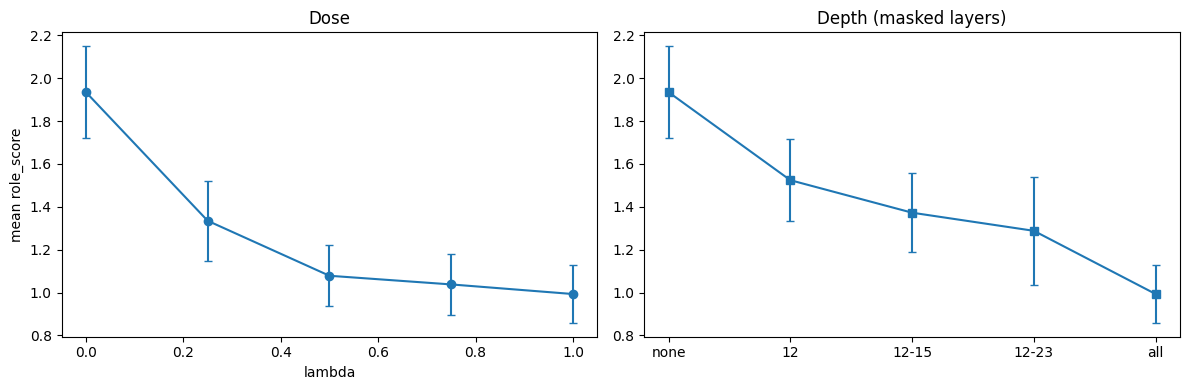

In [ ]:
LAMS=[0.0,0.25,0.5,0.75,1.0]; s20=data.PERSONA_PROMPTS[:20]
dose={L:np.array([sc(gen(p,subspace=subspace,layers=LAYERS,lam=L)) for p in s20]) for L in LAMS}
depth_sets={'none':None,'12':[12],'12-15':list(range(12,16)),'12-23':list(range(12,24)),'all':LAYERS}
depth={k:np.array([sc(gen(p,subspace=subspace,layers=v,lam=1.0)) if v else sc(gen(p)) for p in s20]) for k,v in depth_sets.items()}
fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].errorbar(LAMS,[dose[l].mean() for l in LAMS],yerr=[dose[l].std() for l in LAMS],marker='o',capsize=3)
ax[0].set_xlabel('lambda'); ax[0].set_ylabel('mean role_score'); ax[0].set_title('Dose')
ks=list(depth); ax[1].errorbar(range(len(ks)),[depth[k].mean() for k in ks],yerr=[depth[k].std() for k in ks],marker='s',capsize=3)
ax[1].set_xticks(range(len(ks))); ax[1].set_xticklabels(ks); ax[1].set_title('Depth (masked layers)')
plt.tight_layout(); plt.show()

## Known limitation — overlap with vivid writing (separability + gated mask)

Does the role direction separate pirate from *generic* colorful writing? If the gate
can spare creative text while still suppressing pirate, the limitation is mild; if not,
the overlap is intrinsic.

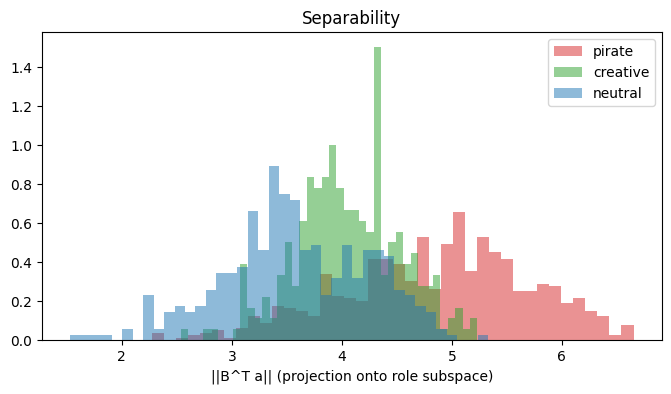

theta=4.49
CREATIVE (want gated ~ base):
  base +1.74 | ungated +0.78 | gated +1.79
  base +1.77 | ungated +1.39 | gated +1.60
  base +1.68 | ungated +1.33 | gated +1.68
PIRATE (want gated suppresses):
  base +1.96 | ungated +1.02 | gated +1.70
  base +2.02 | ungated +1.06 | gated +1.67
  base +1.96 | ungated +0.90 | gated +1.68
  base +2.15 | ungated +0.93 | gated +1.75
  base +1.84 | ungated +0.76 | gated +1.26


In [ ]:
def proj_tokens(texts):
    out=[]
    for t in texts: out.extend(subspace.projection_magnitude(model,tok,t,device).tolist())
    return np.array(out)
pp=proj_tokens([p for _,p in data.PAIRS])
cc=proj_tokens([v for _,v in data.CREATIVE_PAIRS])
nn=proj_tokens([n for n,_ in data.PAIRS])
plt.figure(figsize=(8,4))
for arr,lab,c in [(pp,'pirate','tab:red'),(cc,'creative','tab:green'),(nn,'neutral','tab:blue')]:
    plt.hist(arr,bins=40,alpha=0.5,density=True,label=lab,color=c)
plt.xlabel('||B^T a|| (projection onto role subspace)'); plt.legend(); plt.title('Separability'); plt.show()

theta=float((np.median(cc)+np.median(pp))/2)
cre=['Write a vivid two-sentence description of a thunderstorm.',
     'Describe a bustling night market using colorful language.',
     'Paint a picture of an autumn forest in two sentences.']
pir=data.PERSONA_PROMPTS[:5]
print(f"theta={theta:.2f}")
print("CREATIVE (want gated ~ base):")
for p in cre:
    b=sc(gen(p)); u=sc(gen(p,subspace=subspace,layers=LAYERS,lam=1.0)); g=sc(gen(p,subspace=subspace,layers=LAYERS,lam=1.0,theta=theta))
    print(f"  base {b:+.2f} | ungated {u:+.2f} | gated {g:+.2f}")
print("PIRATE (want gated suppresses):")
for p in pir:
    b=sc(gen(p)); u=sc(gen(p,subspace=subspace,layers=LAYERS,lam=1.0)); g=sc(gen(p,subspace=subspace,layers=LAYERS,lam=1.0,theta=theta))
    print(f"  base {b:+.2f} | ungated {u:+.2f} | gated {g:+.2f}")

## Can we separate pirate from generic colorfulness? (`pure` subspace)

The limitation above is that 𝒢 overlaps vivid writing. Build a *vividness* subspace from
`(plain, vivid)` pairs and remove it from the pirate subspace. If the remainder still
suppresses pirate while sparing creative text, the overlap was an artifact of using one
kind of pair; if it does not, the overlap is intrinsic.

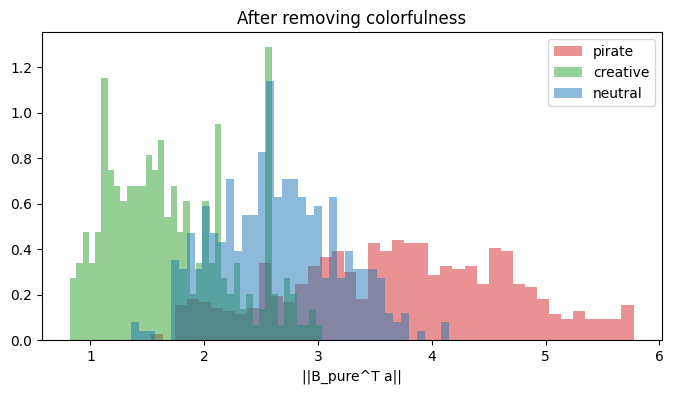

CREATIVE (want pure-mask ~ base):
  base +1.74 | pirate-mask +0.78 | pure-mask +1.66
  base +1.77 | pirate-mask +1.39 | pure-mask +1.66
  base +1.68 | pirate-mask +1.33 | pure-mask +1.57
PIRATE (want pure-mask still suppresses):
  base +1.96 | pirate-mask +1.02 | pure-mask +1.45
  base +2.02 | pirate-mask +1.06 | pure-mask +1.09
  base +1.96 | pirate-mask +0.90 | pure-mask +0.99
  base +2.15 | pirate-mask +0.93 | pure-mask +1.26
  base +1.84 | pirate-mask +0.76 | pure-mask +1.04


In [ ]:
creative_sub = im.build_subspace(model, tok, data.CREATIVE_PAIRS, LAYERS, device,
                                 structural_texts=data.NEUTRAL_PROMPTS[:6])
pure_sub = im.orthogonalize(subspace, creative_sub)   # pirate minus colorfulness

def proj_pure(texts):
    out=[]
    for t in texts: out.extend(pure_sub.projection_magnitude(model,tok,t,device).tolist())
    return np.array(out)
pp=proj_pure([p for _,p in data.PAIRS]); cc=proj_pure([v for _,v in data.CREATIVE_PAIRS]); nn=proj_pure([n for n,_ in data.PAIRS])
plt.figure(figsize=(8,4))
for arr,lab,c in [(pp,'pirate','tab:red'),(cc,'creative','tab:green'),(nn,'neutral','tab:blue')]:
    plt.hist(arr,bins=40,alpha=0.5,density=True,label=lab,color=c)
plt.xlabel('||B_pure^T a||'); plt.legend(); plt.title('After removing colorfulness'); plt.show()

cre=['Write a vivid two-sentence description of a thunderstorm.',
     'Describe a bustling night market using colorful language.',
     'Paint a picture of an autumn forest in two sentences.']
pir=data.PERSONA_PROMPTS[:5]
print("CREATIVE (want pure-mask ~ base):")
for p in cre:
    b=sc(gen(p)); u=sc(gen(p,subspace=subspace,layers=LAYERS,lam=1.0)); pu=sc(gen(p,subspace=pure_sub,layers=LAYERS,lam=1.0))
    print(f"  base {b:+.2f} | pirate-mask {u:+.2f} | pure-mask {pu:+.2f}")
print("PIRATE (want pure-mask still suppresses):")
for p in pir:
    b=sc(gen(p)); u=sc(gen(p,subspace=subspace,layers=LAYERS,lam=1.0)); pu=sc(gen(p,subspace=pure_sub,layers=LAYERS,lam=1.0))
    print(f"  base {b:+.2f} | pirate-mask {u:+.2f} | pure-mask {pu:+.2f}")

## Diagnostic E1 — how 'home-field' is `role_score`?

In [ ]:
cos = (subspace.B[12].T @ sensor.direction).norm().item()
print(f"cos(sensor.direction, subspace[12]) = {cos:.2f}")
s20=data.PERSONA_PROMPTS[:20]
base=np.array([sc(gen(p)) for p in s20])
l12 =np.array([sc(gen(p,subspace=subspace,layers=[12],lam=1.0)) for p in s20])
alll=np.array([sc(gen(p,subspace=subspace,layers=LAYERS,lam=1.0)) for p in s20])
print(f"role: base {base.mean():+.2f} | mask L12-only {l12.mean():+.2f} | mask all {alll.mean():+.2f}")
print("High cos => role_score is a diagnostic; trust the lexicon + formal control for the behavioural claim.")

cos(sensor.direction, subspace[12]) = 0.78
role: base +1.93 | mask L12-only +1.52 | mask all +0.99
High cos => role_score is a diagnostic; trust the lexicon + formal control for the behavioural claim.


## What each section showed

*(the pattern below is what the run produces on Qwen3.5-2B; read the exact numbers off your
own run — they are stated here as the expected, previously-observed result)*

| Section (cell) | What it tests | Result |
|---|---|---|
| **Demo** (11) | mask on / off, one prompt | the pirate register is removed; the model reverts to a plain answer or an "I am an AI" identity line |
| **Main eval N=50** (13) | suppression + independent lexicon | the pirate-lexicon count drops ≈ to 0 and `role_score` drops strongly; a fraction of masked outputs revert to "I am an AI" (the **expected** identity cascade, not a failure), so the honest figure is the lexicon on the **non-meta** subset |
| **Concept-specificity** (15) | formal & random subspaces | **neither** suppresses pirate (≈ baseline) while the pirate subspace does — the effect is **concept-specific**, not generic K-dimension removal |
| **Capability** (17) | factual prompts under the mask | ordinary answers are preserved — the mask removes the register, not the competence |
| **Dose & depth** (19) | `λ`-sweep and layer-subset sweep | suppression grows monotonically with `λ`; masking a band of mid/late layers ≈ masking all layers |
| **Separability** (21) | `‖Bᵀa‖` histograms + gated `θ` | pirate and creative loadings **overlap**; the `θ`-gate spares creative text only at the cost of weaker pirate suppression — no clean separation |
| **Pure subspace** (23) | pirate **minus** colorfulness | after removing a vividness subspace the remainder still suppresses pirate, but creative text is also still affected — the overlap is **largely intrinsic**, not just an artifact of one kind of pair |
| **E1 home-field** (25) | cos(probe, masked subspace) | cos ≈ 0.78 → `role_score` is partly circular; the behavioural claim therefore rests on the **lexicon + controls**, not on `role_score` |

**Bottom line.** The mask suppresses the pirate register concept-specifically and without
breaking capability; the honest caveat is that the direction is a broad expressive register
(pirate ≈ creative on the role axis), and `role_score` is a home-field diagnostic — hence the
claim leans on the independent lexicon and the formal/random controls.
